# Endogenous Technology Learning

*IR, June 2026*

Endogenous technology learning concept implies, put short, that technology gets cheaper the more of it we build.

In modelling language, endogenous learning in capacity expansion models means that optimization problem includes a feedback loop between the **capacity built** and the **cost of building**. In other words, the decision to choose such a technology *before* it is competitive, the optimiser must see that building it today buys experience that lowers tomorrow's cost.

This notebook walks through the same toy problem solved **five different ways**,
from a smooth non-linear reference to the linearised mixed-integer formulations.

| # | Model | Experience axis $E$ | Cost approximation | Tool stack |
|---|-------|---------------------|--------------------|--------------|
| 1 | NLP reference | cumulative built [MW] | true smooth $c(E)$ | `pyomo` + `ipopt` |
| 2 | MILP, midpoint-constant | cumulative built [MW] | step $c(E)$, 10 seg | `pypsa` + `linopy`|
| 3 | MILP, chord-linear | cumulative built [MW] | chord $c(E)$, 6 seg | `pypsa` + `linopy`|
| 4 | MILP, TC(E) Barreto | cumulative built [MW] | chord $TC(E)$, 5 seg | `pypsa` + `linopy`|
| 5 | MILP, time-delay | cumulative built [MW] | chord $TC(E)$, 5 seg | `pypsa` + `linopy`|

At the very end of the notebook we bring all results to a dashboard.

> The economic problem in one breath: 50 yearly periods, a flat **100 MW**
> demand, three technologies (**coal**, **nuclear**, **CSP**) and a **CO₂
> budget** that forces decarbonisation. CSP starts at more expensive cost than nuclear but learns. Nuclear does not learn really, as we all know it.


## The learning curve (shared by all five models)

The annuity-equivalent capex of the next MW of Concentrated Solar Power (CSP), when cumulative experience is
$E$, follows a **learning curve**

$$c(E) = c_{\text{base}} + (c_0 - c_{\text{base}})\,(1+E)^{-\gamma},$$

with $c_0 = 150\,\text{€/MWh}\times 8760$ (first MW), $c_{\text{base}} =
20\,\text{€/MWh}\times 8760$ (floor) and $\gamma = 0.333$. 
The "$1+E$" keeps
$c(0)=c_0$ finite — *you start with one unit of experience*. 
The $\times 8760$ is just a scaling factor: it turns €/MWh into a per-MW annuity for a year collapsed to a
single snapshot.

In [1]:
import logging

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pypsa

plt.style.use("bmh")
logging.getLogger("pypsa").setLevel(logging.WARNING)
logging.getLogger("linopy").setLevel(logging.WARNING)

# ---- shared parameters -------------------------------------------------------
YEARS = list(range(2020, 2070))
Y0 = YEARS[0]
A_LEN = len(YEARS)
RATE = 0.05  # discount rate
DEMAND = 100.0  # MW (flat)
CO2_BUDGET = 0.2  # average tCO2/MWh

TECHS = ["coal", "nuclear", "CSP"]
COLORS = ["#707070", "#ff9000", "#f9d002"]

ANNUITY = {"coal": 15.0 * 8760, "nuclear": 65.0 * 8760, "CSP": 150.0 * 8760}
ANNUITY_BASE = {"CSP": 20.0 * 8760}
MARGINAL = {"coal": 35.0, "nuclear": 10.0, "CSP": 0.0}
EMISSIONS = {"coal": 1.0, "nuclear": 0.0, "CSP": 0.0}
LIFETIME = {"coal": 40, "nuclear": 40, "CSP": 30}
EXIST_CAP = {"coal": 100.0, "nuclear": 0.0, "CSP": 0.0}
EXIST_AGE = {"coal": 20, "nuclear": 0, "CSP": 0}

GAMMA = 0.333
C0 = ANNUITY["CSP"]  # cost of the first MW
CB = ANNUITY_BASE["CSP"]  # learning floor


def discount(a):
    """Period discount factor."""
    return 1.0 / (1.0 + RATE) ** (a - Y0)


def adf(build_year, lifetime):
    """Sum of period discount factors over a build's active years."""
    return sum(discount(b) for b in YEARS if build_year <= b < build_year + lifetime)


def c_csp(E):
    """Specific CSP cost (annuity per MW) at experience E."""
    return CB + (C0 - CB) * (1.0 + E) ** (-GAMMA)


def tc_csp(E):
    """Cumulative CSP cost = integral of c(E') from 0 to E."""
    return CB * E + (C0 - CB) / (1.0 - GAMMA) * ((1.0 + E) ** (1.0 - GAMMA) - 1.0)


def coal_constant():
    """NPV of the annuities of the pre-existing coal fleet (added to every objective)."""
    return sum(
        EXIST_CAP[t] * ANNUITY[t] / 1e6 * discount(a)
        for t in TECHS
        for a in YEARS
        if a < Y0 + LIFETIME[t] - EXIST_AGE[t]
    )


RESULTS = {}  # prefix -> solved data, reused by the final dashboard

### Shared helpers

Models 2–5 share the same PyPSA network (one extendable generator per
technology-and-build-year, an existing coal fleet, a CO₂ budget). They differ
only in the **learning block** patched onto the `linopy` model. We factor out
the common parts so each model section can focus on its learning math.


In [2]:
def build_network(p_nom_max=None):
    """Toy multi-investment-period network shared by all MILP models.

    CSP generators carry ``capital_cost = 0`` -- their capex is supplied by the
    learning block added later. ``p_nom_max`` caps per-year builds (needed as a
    Big-M for the midpoint/chord models, left open for the TC(E) models).
    """
    n = pypsa.Network()
    n.snapshots = pd.MultiIndex.from_product(
        [YEARS, [pd.Timestamp("2020-01-01")]], names=["period", "timestep"]
    )
    n.investment_periods = YEARS
    n.investment_period_weightings["years"] = 1.0
    n.investment_period_weightings["objective"] = [discount(a) for a in YEARS]
    n.snapshot_weightings.loc[:, ["objective", "generators", "stores"]] = 8760.0

    n.add("Bus", "bus")
    n.add("Load", "load", bus="bus", p_set=DEMAND)
    for t in TECHS:
        n.add("Carrier", t, co2_emissions=EMISSIONS[t])

    n.add(
        "Generator",
        "coal_existing",
        bus="bus",
        carrier="coal",
        p_nom=EXIST_CAP["coal"],
        p_nom_extendable=False,
        build_year=Y0 - EXIST_AGE["coal"],
        lifetime=LIFETIME["coal"],
        marginal_cost=MARGINAL["coal"],
    )

    for tech in TECHS:
        for a in YEARS:
            kw = {} if p_nom_max is None else {"p_nom_max": p_nom_max}
            n.add(
                "Generator",
                f"{tech}_{a}",
                bus="bus",
                carrier=tech,
                p_nom_extendable=True,
                build_year=a,
                lifetime=LIFETIME[tech],
                marginal_cost=MARGINAL[tech],
                capital_cost=(ANNUITY[tech] if tech != "CSP" else 0.0),
                **kw,
            )

    n.add(
        "GlobalConstraint",
        "co2_budget",
        type="primary_energy",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=CO2_BUDGET * A_LEN * DEMAND * 8760.0,
    )
    return n


def extract_pypsa(n):
    """Pull per-year dispatch, installed capacity and new builds from a solved network."""
    dispatch = pd.DataFrame(0.0, index=YEARS, columns=TECHS)
    capacity = pd.DataFrame(0.0, index=YEARS, columns=TECHS)
    builds = pd.DataFrame(0.0, index=YEARS, columns=TECHS)
    for (a, _), row in n.generators_t.p.iterrows():
        for g, val in row.items():
            dispatch.at[a, n.generators.at[g, "carrier"]] += val
    for g, info in n.generators.iterrows():
        cap = info.p_nom_opt if info.p_nom_extendable else info.p_nom
        for a in YEARS:
            if info.build_year <= a < info.build_year + int(info.lifetime):
                capacity.at[a, info.carrier] += cap
        if info.p_nom_extendable and info.build_year in YEARS:
            builds.at[info.build_year, info.carrier] = cap
    return dispatch.clip(lower=0), capacity.clip(lower=0), builds


def milp_lcoe(E_opt):
    """LCOE per tech: flat annuities for coal/nuclear, learned curve for CSP."""
    lcoe = pd.DataFrame(index=YEARS, columns=TECHS, dtype=float)
    for t in ["coal", "nuclear"]:
        lcoe[t] = ANNUITY[t] / 8760.0 + MARGINAL[t]
    lcoe["CSP"] = (
        pd.Series({a: c_csp(E_opt[a]) / 8760.0 for a in YEARS}) + MARGINAL["CSP"]
    )
    return lcoe


def save_results(prefix, dispatch, capacity, lcoe, obj):
    """Write a CSV in the comparison format and stash the frames in RESULTS."""
    parts = []
    for name, df in [("dispatch", dispatch), ("capacity", capacity), ("lcoe", lcoe)]:
        tmp = df.copy()
        tmp.index = pd.MultiIndex.from_tuples([(name, str(a)) for a in tmp.index])
        parts.append(tmp)
    meta = pd.DataFrame({"value": {"objective": obj}})
    meta.index = pd.MultiIndex.from_tuples([("meta", k) for k in meta.index])
    for t in TECHS:
        meta[t] = float("nan")
    pd.concat(parts + [meta]).to_csv(f"{prefix}.csv")
    RESULTS[prefix] = dict(
        obj=obj,
        dispatch=dispatch,
        capacity=capacity,
        lcoe=lcoe,
    )


def make_title(model, axis, approx, segs, npv):
    """Multi-line panel title in the style of the reference comparison figure."""
    parts = [model, axis, approx]
    if segs is not None:
        parts.append(f"{segs} segments")
    if npv is not None:
        parts.append(f"NPV: {npv:.0f} bn EUR")
    return "\n".join(parts)


# ---- cost-curve approximation panels ----------------------------------------
def plot_approx_c(ax, E_break, mode):
    """Panel of the smooth c(E)/8760 with an optional PWL overlay (log-x)."""
    E_dense = np.expm1(np.linspace(0, np.log1p(E_break[-1]), 1000))
    ax.plot(
        1.0 + E_dense, c_csp(E_dense) / 8760.0, "k-", lw=1.5, label="true c(E)/8760"
    )
    if mode == "midpoint":
        c_mid = 0.5 * (c_csp(E_break[:-1]) + c_csp(E_break[1:])) / 8760.0
        for el, er, cm in zip(E_break[:-1], E_break[1:], c_mid):
            ax.hlines(cm, 1.0 + el, 1.0 + er, colors="C3", lw=2)
        ax.scatter(
            1.0 + 0.5 * (E_break[:-1] + E_break[1:]),
            c_mid,
            s=20,
            c="C3",
            zorder=3,
            label="midpoint-const PWL",
        )
    elif mode == "chord":
        ax.plot(
            1.0 + E_break,
            c_csp(E_break) / 8760.0,
            "C0o-",
            lw=2,
            ms=4,
            label="chord-linear PWL",
        )
    ax.set_xscale("log")
    ax.set_xlim(1.0, 1.0 + E_break[-1])
    ax.set_ylim(0, 160)
    ax.set_xlabel("1 + E   [MW]  (cumulative built)")
    ax.set_ylabel("c(E)/8760  [EUR/MWh]")
    ax.legend(fontsize=9, loc="upper right")


def plot_approx_TC(ax, E_break):
    """Panel of the smooth TC(E) with its chord-linear PWL overlay."""
    E_dense = np.linspace(0, E_break[-1], 500)
    ax.plot(E_dense, tc_csp(E_dense) / 1e6, "k-", lw=1.5, label="true TC(E)")
    ax.plot(
        E_break, tc_csp(E_break) / 1e6, "C0o-", lw=2, ms=4, label="chord-linear PWL"
    )
    ax.set_xlim(0, E_break[-1])
    ax.set_xlabel("E  [MW]  (cumulative built)")
    ax.set_ylabel("TC(E)  [bn EUR]")
    ax.legend(fontsize=9, loc="lower right")


def dashboard(title, dispatch, capacity, lcoe, approx):
    """Four-panel per-model dashboard: dispatch, capacity, LCOE, cost-curve approx."""
    dispatch = dispatch.clip(lower=0)
    capacity = capacity.clip(lower=0)
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    dispatch.plot(kind="area", stacked=True, color=COLORS, ax=axes[0, 0], linewidth=0)
    axes[0, 0].set_title("dispatch")
    axes[0, 0].set_ylabel("MW")
    axes[0, 0].set_ylim(0, 110)
    axes[0, 0].set_xlabel("")

    capacity.plot(kind="area", stacked=True, color=COLORS, ax=axes[0, 1], linewidth=0)
    axes[0, 1].set_title("installed capacity")
    axes[0, 1].set_ylabel("MW")
    axes[0, 1].set_ylim(0, 210)
    axes[0, 1].set_xlabel("")

    lcoe.plot(color=COLORS, ax=axes[1, 0], linewidth=2)
    axes[1, 0].set_title("LCOE per technology")
    axes[1, 0].set_ylabel("EUR/MWh")
    axes[1, 0].set_ylim(0, 160)
    axes[1, 0].set_xlabel("year")

    approx(axes[1, 1])
    axes[1, 1].set_title("cost-curve approximation")

    fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

## Model 1 — Non-linear reference (`pyomo` + `ipopt`)

> **Stack:** `pyomo` builds the model, `ipopt` (an interior-point NLP solver)
> solves it. This is the only model that keeps the learning curve **smooth**.

This is Tom Brown's lecture toy model: https://nworbmot.org/courses/es-25/es-12-dynamics.pdf

The full problem in compact form:

**Decision variables**

| Symbol | Meaning |
|--------|---------|
| $g_{s,a}\ge 0$ | dispatch of technology $s$ in year $a$ [MW] |
| $Q_{s,a}\ge 0$ | new capacity built for technology $s$ in year $a$ [MW] |
| $c_{s,a}\ge 0$ | specific cost (annuity per MW) of technology $s$ in year $a$ |

**Objective** — minimise discounted total system cost:

$$\min \sum_{s,\,a} \frac{1}{10^6\,(1+r)^{a-a_0}}
\left(
  o_{s,a}\cdot g_{s,a}\cdot 8760
  \;+\;
  \sum_{b\,:\,b\le a < b+L_s} c_{s,b}\,Q_{s,b}
\right)$$

The inner sum charges the annuity of every build $Q_{s,b}$ in all years during which it is still active ($b \le a < b+L_s$).

**Constraints**

$$\forall a:\quad \sum_s g_{s,a} = d \qquad\text{(demand met)}$$

$$\forall s,a:\quad g_{s,a} \le G_{s,a} \qquad\text{(capacity limit)}$$

$$\sum_{s,a} g_{s,a}\cdot e_s \;\le\; \hat{e}\cdot|A|\cdot d \qquad\text{(CO}_2\text{ budget)}$$

**Learning coupling** — what makes the problem non-linear:

$$c_{s,a} = c_{\text{base},s} + (c_{0,s}-c_{\text{base},s})\left(\frac{x_0 + \sum_{b<a} Q_{s,b}}{x_0}\right)^{-\gamma_s}$$

The exponent $\gamma_s$ is the **learning index**, related to the **Learning Rate** $LR_s$ (the fractional cost reduction each time cumulative capacity doubles), such that by $\gamma_s = -\log_2(1-LR_s)$. For CSP with $LR=20\%$: $\gamma = -\log_2(0.8) \approx 0.322$.

$c_{s,a}$ depends on $\sum_{b<a}Q_{s,b}$, and it multiplies $Q_{s,b}$ in the objective. So we get a **product of two decision variables**, making the problem non-convex. `ipopt` handles it directly with interior-point method.

In [3]:
from pyomo.environ import (
    ConcreteModel,
    Var,
    Objective,
    Constraint,
    NonNegativeReals,
)
from pyomo.opt import SolverFactory
import shutil

# learning curve here uses the lecture's "potential annuity" floor of 20 EUR/MWh
params = pd.DataFrame(columns=TECHS)
params.loc["current annuity"] = [15.0 * 8760, 65.0 * 8760, 150.0 * 8760]
params.loc["potential annuity"] = [15.0 * 8760, 65.0 * 8760, 20.0 * 8760]
params.loc["learning parameter"] = [0.0, 0.0, 0.333]
params.loc["marginal cost"] = [35.0, 10.0, 0.0]
params.loc["specific emissions"] = [1.0, 0.0, 0.0]
params.loc["lifetime"] = [40, 40, 30]
params.loc["existing age"] = [20, 0, 0]
params.loc["existing capacity"] = [100, 0, 0]
params.loc["cumulative capacity"] = [1, 1, 1]

model = ConcreteModel("NLP reference")
model.generators_dispatch = Var(TECHS, YEARS, within=NonNegativeReals)
model.generators_built = Var(TECHS, YEARS, within=NonNegativeReals)
model.fixed_costs = Var(TECHS, YEARS, within=NonNegativeReals)

constant = sum(
    params.at["existing capacity", t]
    * params.at["current annuity", t]
    / 1e6
    * discount(a)
    for t in TECHS
    for a in YEARS
    if a < Y0 + params.at["lifetime", t] - params.at["existing age", t]
)

model.objective = Objective(
    expr=constant
    + sum(
        model.generators_built[t, a]
        * model.fixed_costs[t, a]
        / 1e6
        * sum(discount(b) for b in YEARS if a <= b < a + params.at["lifetime", t])
        for a in YEARS
        for t in TECHS
    )
    + sum(
        model.generators_dispatch[t, a]
        * params.at["marginal cost", t]
        * 8760
        / 1e6
        * discount(a)
        for a in YEARS
        for t in TECHS
    )
)


def balance(model, a):
    return DEMAND == sum(model.generators_dispatch[t, a] for t in TECHS)


def gen_limit(model, t, a):
    c = (
        params.at["existing capacity", t]
        if a < Y0 + params.at["lifetime", t] - params.at["existing age", t]
        else 0.0
    )
    return model.generators_dispatch[t, a] <= c + sum(
        model.generators_built[t, b]
        for b in YEARS
        if a >= b and a < b + params.at["lifetime", t]
    )


def co2(model):
    return CO2_BUDGET * len(YEARS) * DEMAND >= sum(
        model.generators_dispatch[t, a] * params.at["specific emissions", t]
        for t in TECHS
        for a in YEARS
    )


def fixed_cost(model, t, a):
    if params.at["learning parameter", t] == 0:
        return model.fixed_costs[t, a] == params.at["current annuity", t]
    cum = params.at["cumulative capacity", t] + sum(
        model.generators_built[t, b] for b in YEARS if b < a
    )
    return model.fixed_costs[t, a] == params.at["potential annuity", t] + (
        params.at["current annuity", t] - params.at["potential annuity", t]
    ) * (cum / params.at["cumulative capacity", t]) ** (
        -params.at["learning parameter", t]
    )


model.balance = Constraint(YEARS, rule=balance)
model.gen_limit = Constraint(TECHS, YEARS, rule=gen_limit)
model.co2 = Constraint(rule=co2)
model.fixed_cost = Constraint(TECHS, YEARS, rule=fixed_cost)

ipopt = shutil.which("ipopt") or "/home/iriepin/miniconda3/envs/res-profiles/bin/ipopt"
opt = SolverFactory("ipopt", executable=ipopt)
opt.solve(model, keepfiles=False)
obj = model.objective()
print(f"NLP objective: {obj:.1f} bn EUR (NPV)")


NLP objective: 1031.5 bn EUR (NPV)


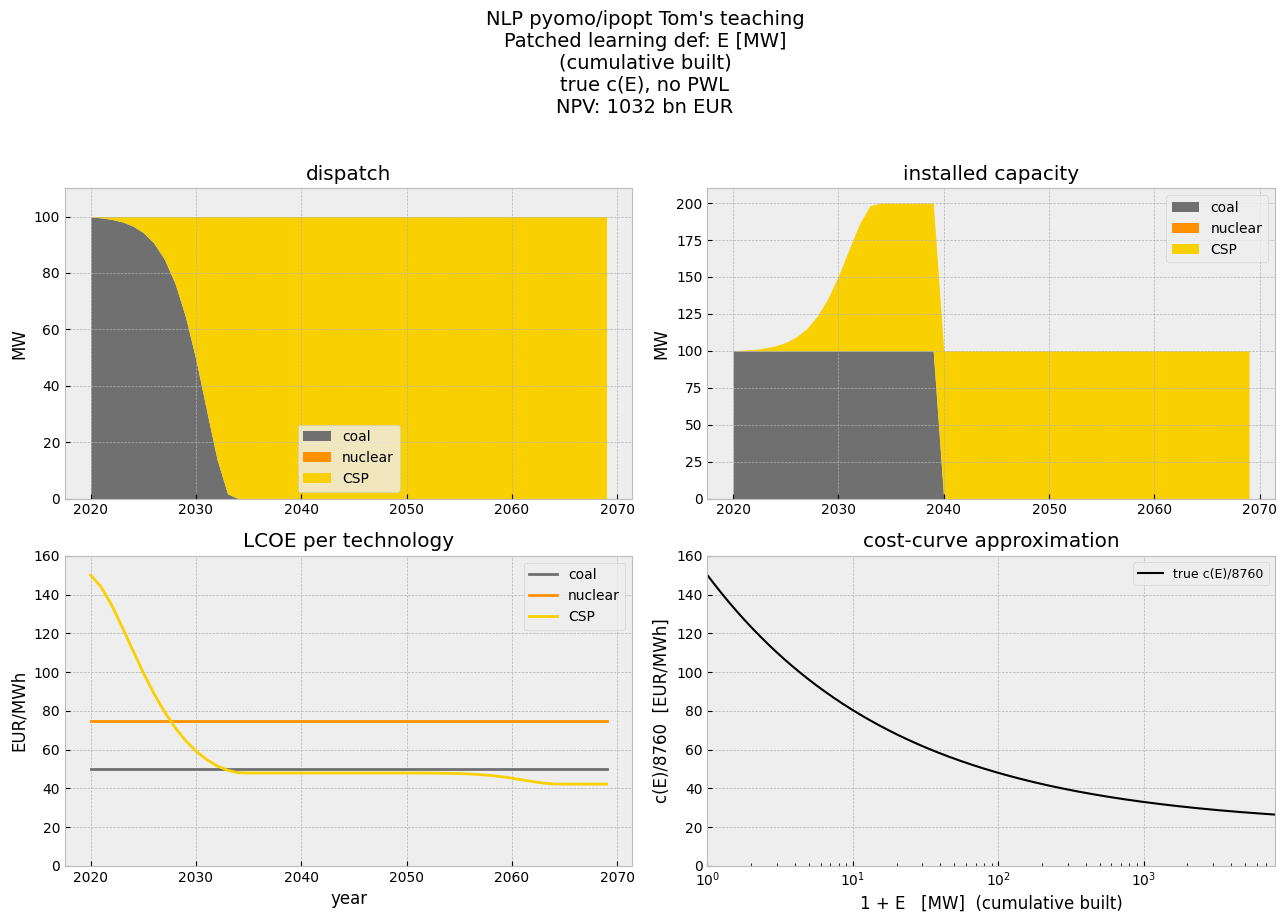

In [4]:
# ---- extract results --------------------------------------------------------
dispatch = pd.DataFrame(0.0, index=YEARS, columns=TECHS)
capacity = pd.DataFrame(0.0, index=YEARS, columns=TECHS)
lcoe = pd.DataFrame(0.0, index=YEARS, columns=TECHS)
for a in YEARS:
    for t in TECHS:
        dispatch.at[a, t] = model.generators_dispatch[t, a].value
        c = (
            EXIST_CAP[t]
            if a < Y0 + params.at["lifetime", t] - params.at["existing age", t]
            else 0.0
        )
        capacity.at[a, t] = c + sum(
            model.generators_built[t, b].value
            for b in YEARS
            if a >= b and a < b + params.at["lifetime", t]
        )
        lcoe.at[a, t] = (
            model.fixed_costs[t, a].value / 8760.0 + params.at["marginal cost", t]
        )

dispatch = dispatch.clip(lower=0)
save_results("ipopt", dispatch, capacity, lcoe, obj)

dashboard(
    make_title(
        "NLP pyomo/ipopt Tom's teaching",
        "Patched learning def: E [MW]\n(cumulative built)",
        "true c(E), no PWL",
        None,
        obj,
    ),
    dispatch,
    capacity,
    lcoe,
    lambda ax: plot_approx_c(ax, np.array([0.0, 8000.0]), "true"),
)


## Model 2 — MILP, midpoint-constant $c(E)$ (`pypsa` + `linopy`)

> **Stack:** `pypsa` builds the network, the learning block is patched onto the
> `linopy` model, `gurobi` (or another MILP solver) solves the MILP.

The learning objective contains a product $c(E_a)\cdot Q_a$ that is **bilinear** and non-convex, so we can't hand it to a MILP solver directly. However, we can approximate $c(E)$ by a **step function** (one constant value
per segment) and replace the bilinear product with a new variable.

**Segment selection.** Partition the experience axis into $N=10$ log-spaced
breakpoints $E_0<E_1<\cdots<E_N$. Introduce binary $y_{a,j}\in\{0,1\}$ with

$$\sum_j y_{a,j}=1 \quad\forall\,a,\qquad y_{a,j}=1\;\Rightarrow\; E_a\in[E_j,E_{j+1}],$$

so exactly one segment is "active" in each year $a$.

**Big-M linearisation.** Define $z_{a,j}=y_{a,j}\cdot Q_a\ge 0$.
Since $y_{a,j}\in\{0,1\}$ and $Q_a\le Q_{\max}$, the product is captured exactly by

$$z_{a,j}\le Q_{\max}\,y_{a,j},\qquad \sum_j z_{a,j}=Q_a.$$

**Experience tracking.** Cumulative built experience:

$$E_a = \sum_{b<a} Q_b.$$

**Objective patch.** CSP `capital_cost` is set to 0; the learning cost is
added as

$$\text{extra} = \sum_a \sum_j c^{\text{mid}}_j\,z_{a,j}\;\cdot\;\mathrm{adf}(a,L_\text{CSP}),
\qquad c^{\text{mid}}_j = \tfrac{1}{2}\bigl(c(E_j)+c(E_{j+1})\bigr).$$

Because $c(E)$ is **convex**, the midpoint lies *below* the chord, so this slightly
**under-estimates** true learning costs — the NPV comes in a few % below Model 1.
The policy shape (CSP entry timing, coal phase-out) is unaffected.

In [5]:
# ---- midpoint-constant PWL of c(E) on log-spaced breakpoints ----------------
N_SEG_MID = 10
E_MAX_MID = 8000.0  # MW, generous upper bound on cumulative built
E_BREAK_MID = np.expm1(np.linspace(0.0, np.log1p(E_MAX_MID), N_SEG_MID + 1))
C_MID = 0.5 * (c_csp(E_BREAK_MID[:-1]) + c_csp(E_BREAK_MID[1:]))
Q_MAX = 200.0  # MW — Big-M on per-year CSP build


def add_learning_midpoint(n):
    m = n.model
    period = pd.Index(YEARS, name="period")
    seg = pd.Index(range(N_SEG_MID), name="seg")

    y = m.add_variables(binary=True, coords=[period, seg], name="csp_y")
    E = m.add_variables(lower=0.0, upper=E_MAX_MID, coords=[period], name="csp_E")
    Q = m.add_variables(lower=0.0, coords=[period], name="csp_Q")
    z = m.add_variables(lower=0.0, coords=[period, seg], name="csp_z")  # y * Q

    m.add_constraints(y.sum("seg") == 1, name="csp_y_sum")
    EL = xr.DataArray(E_BREAK_MID[:-1], coords=[seg], dims=["seg"])
    ER = xr.DataArray(E_BREAK_MID[1:], coords=[seg], dims=["seg"])
    m.add_constraints(1.0 * E - (y * EL).sum("seg") >= 0, name="csp_E_lo")
    m.add_constraints(1.0 * E - (y * ER).sum("seg") <= 0, name="csp_E_hi")
    m.add_constraints(z - Q_MAX * y <= 0, name="csp_z_BM")
    m.add_constraints(z.sum("seg") - 1.0 * Q == 0, name="csp_z_sum")

    p_nom = m["Generator-p_nom"]
    for i, a in enumerate(YEARS):
        m.add_constraints(Q.at[a] - p_nom.at[f"CSP_{a}"] == 0, name=f"csp_Q_tie_{a}")
        if i == 0:
            m.add_constraints(E.at[a] == 0, name=f"csp_E_def_{a}")
            continue
        names = [f"CSP_{b}" for b in YEARS if b < a]  # E = cumulative built
        coef = xr.DataArray([1] * len(names), coords={"name": names}, dims=["name"])
        lhs = (p_nom.sel(name=names) * coef).sum("name") - (1.0 * E.at[a]).to_linexpr()
        m.add_constraints(lhs == 0, name=f"csp_E_track_{a}")

    cm = xr.DataArray(C_MID, coords=[seg], dims=["seg"])
    adf_arr = xr.DataArray(
        [adf(a, LIFETIME["CSP"]) for a in YEARS], coords=[period], dims=["period"]
    )
    m.add_objective(m.objective.expression + (z * cm * adf_arr).sum(), overwrite=True)


n = build_network(p_nom_max=Q_MAX)
n.optimize.create_model(multi_investment_periods=True)
add_learning_midpoint(n)
n.optimize.solve_model(solver_name="gurobi", solver_options={"OutputFlag": 0})
obj = float(n.model.objective.value) / 1e6 + coal_constant()
print(f"MILP midpoint: NPV={obj:.1f} bn EUR")


Index(['bus'], dtype='object', name='name')
/tmp/ipykernel_848742/1624936820.py:46: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.



Set parameter TokenServer to value "license.ensys.tu-berlin.de"


INFO:gurobipy:Set parameter TokenServer to value "license.ensys.tu-berlin.de"


Read LP format model from file /tmp/linopy-problem-9wir7ujw.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-9wir7ujw.lp


Reading time = 0.01 seconds


INFO:gurobipy:Reading time = 0.01 seconds


obj: 8201 rows, 4775 columns, 20095 nonzeros


INFO:gurobipy:obj: 8201 rows, 4775 columns, 20095 nonzeros


MILP midpoint: NPV=1006.1 bn EUR


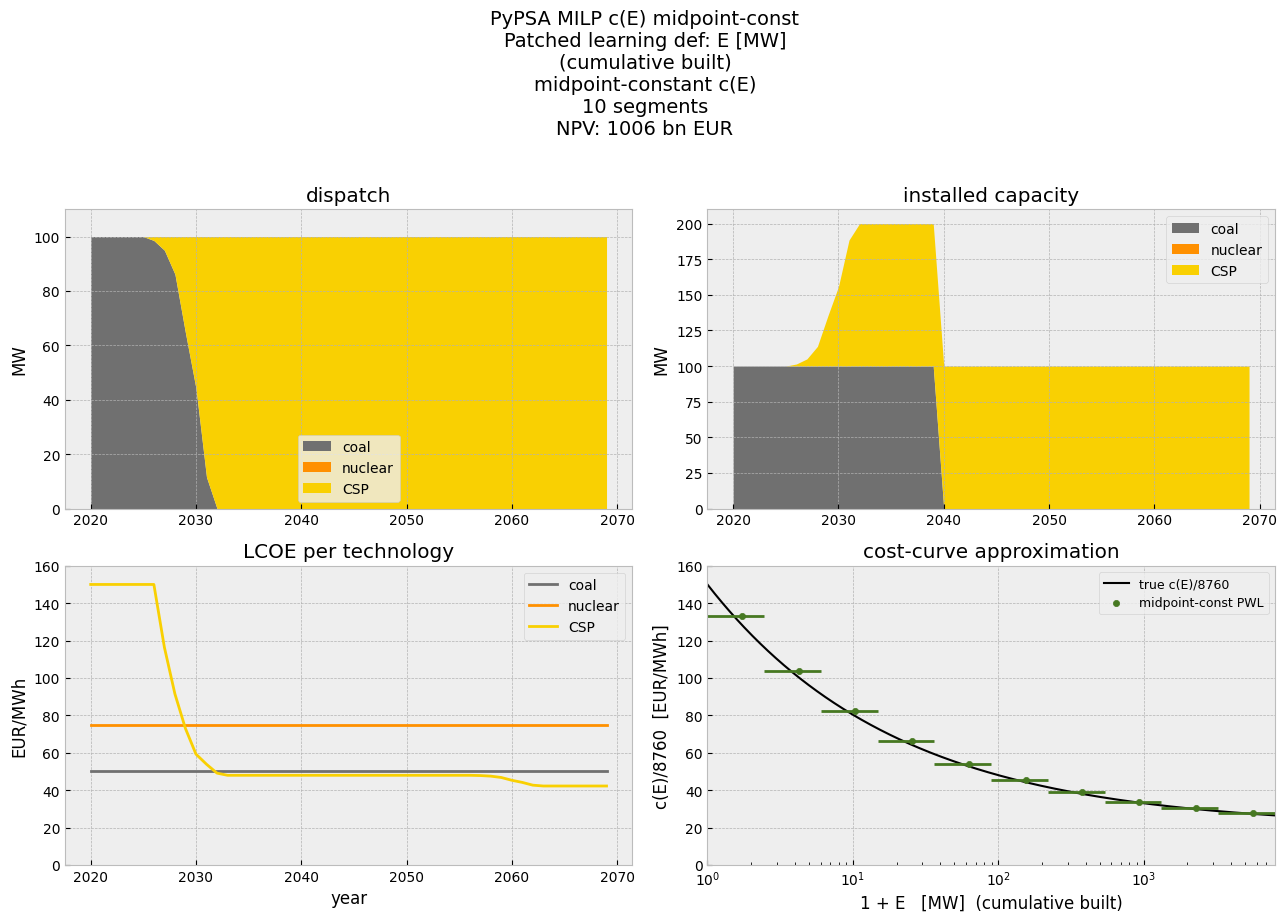

In [6]:
dispatch, capacity, _ = extract_pypsa(n)
E_opt = n.model["csp_E"].solution.to_pandas()
lcoe = milp_lcoe(E_opt)
save_results("milp_notebook", dispatch, capacity, lcoe, obj)

dashboard(
    make_title(
        "PyPSA MILP c(E) midpoint-const",
        "Patched learning def: E [MW]\n(cumulative built)",
        "midpoint-constant c(E)",
        N_SEG_MID,
        obj,
    ),
    dispatch,
    capacity,
    lcoe,
    lambda ax: plot_approx_c(ax, E_BREAK_MID, "midpoint"),
)


## Model 3 — MILP, chord-linear $c(E)$ (`pypsa` + `linopy`)

> **Stack:** same as model 2; only the approximation of $c(E)$ changes.

> Well, chord-linear $c(E)$ happened to be such a headache! **Don't use this formulation.** It is here just to document my attempts. It can be made to work with SOS2 variables but we anyway are mostly interested in the TC(E) formulation (Model 4) that avoids bilinearity entirely.

Model 2 assigned a single flat cost to each segment (the midpoint value). Model 3 instead
draws a **chord** between the two endpoints — a linear interpolation that is exact at the
breakpoints and approximates $c(E)$ linearly in between.

**Segment selection** works the same way as Model 2: binary $y_{a,j}\in\{0,1\}$ with
$\sum_j y_{a,j}=1\;\forall a$ selects one active segment per year.

**Convex weights** $\lambda^L_{a,j},\lambda^R_{a,j}\ge 0$ place $E_a$ on the chord
of the active segment:

$$\lambda^L_{a,j}+\lambda^R_{a,j} = y_{a,j}, \qquad
E_a = \sum_j\bigl(\lambda^L_{a,j}E_j+\lambda^R_{a,j}E_{j+1}\bigr).$$

When $y_{a,j}=0$, both weights are forced to zero; when $y_{a,j}=1$, the weights
are non-negative and sum to 1 — a convex combination pinned to the $j$-th chord.

**Linearised cost** — two auxiliary variables per (year, segment) carry left and right
endpoint costs:

$$z^L_{a,j} \le Q_{\max}\,\lambda^L_{a,j}, \qquad z^R_{a,j} \le Q_{\max}\,\lambda^R_{a,j},
\qquad \sum_j(z^L_{a,j}+z^R_{a,j}) = Q_a,$$

$$\text{cost}_a = \sum_j\bigl(c(E_j)\,z^L_{a,j}+c(E_{j+1})\,z^R_{a,j}\bigr).$$

**⚠ The problem** Here $z^L = \lambda^L Q$ and $z^R = \lambda^R Q$ are products of two continuous variables. The upper bounds alone don't couple them: with $Q \ll Q_{\max}$, the solver is free to set $z^L = 0$, $z^R = Q$ This prices every unit at the **right-endpoint cost** $c(E_{j+1})$ — the cheapest value in the active segment — regardless of where $\lambda$ places $E_a$ on the chord. So I interpret it as that the chord geometry for $E$ tracking is correct; but the cost assignment is really loose.
Because $c$ is decreasing, right-endpoint pricing is cheaper than both the chord and the true curve, so Model 3 under-estimates costs and its NPV falls below the NLP reference. Models 2 and 4 avoid this bilinearity entirely: Model 2 uses a constant cost per segment (no product needed); Model 4 prices investments via the $TC$ integral difference (also no product needed).


In [7]:
# ---- chord-linear PWL of c(E) -----------------------------------------------
N_SEG_CHORD = 6
E_MAX_CHORD = 8000.0
E_BREAK_CHORD = np.expm1(np.linspace(0.0, np.log1p(E_MAX_CHORD), N_SEG_CHORD + 1))
C_LEFT = c_csp(E_BREAK_CHORD[:-1])
C_RIGHT = c_csp(E_BREAK_CHORD[1:])


def add_learning_chord(n):
    m = n.model
    period = pd.Index(YEARS, name="period")
    seg = pd.Index(range(N_SEG_CHORD), name="seg")

    y = m.add_variables(binary=True, coords=[period, seg], name="csp_y")
    lamL = m.add_variables(lower=0.0, coords=[period, seg], name="csp_lamL")
    lamR = m.add_variables(lower=0.0, coords=[period, seg], name="csp_lamR")
    E = m.add_variables(lower=0.0, upper=E_MAX_CHORD, coords=[period], name="csp_E")
    Q = m.add_variables(lower=0.0, coords=[period], name="csp_Q")
    zL = m.add_variables(lower=0.0, coords=[period, seg], name="csp_zL")
    zR = m.add_variables(lower=0.0, coords=[period, seg], name="csp_zR")

    m.add_constraints(y.sum("seg") == 1, name="csp_y_sum")
    m.add_constraints(lamL + lamR - y == 0, name="csp_lam_eq")
    EL = xr.DataArray(E_BREAK_CHORD[:-1], coords=[seg], dims=["seg"])
    ER = xr.DataArray(E_BREAK_CHORD[1:], coords=[seg], dims=["seg"])
    m.add_constraints(
        (lamL * EL + lamR * ER).sum("seg") - 1.0 * E == 0, name="csp_E_def"
    )
    # Upper bounds only: zL ≤ Q_MAX*lamL, zR ≤ Q_MAX*lamR (loose when Q << Q_MAX;
    # solver sets zL=0, zR=Q i.e. right-endpoint pricing; see markdown for details)
    m.add_constraints(zL - Q_MAX * lamL <= 0, name="csp_zL_BM")
    m.add_constraints(zR - Q_MAX * lamR <= 0, name="csp_zR_BM")
    m.add_constraints((zL + zR).sum("seg") - 1.0 * Q == 0, name="csp_z_sum")

    p_nom = m["Generator-p_nom"]
    for i, a in enumerate(YEARS):
        m.add_constraints(Q.at[a] - p_nom.at[f"CSP_{a}"] == 0, name=f"csp_Q_tie_{a}")
        if i == 0:
            m.add_constraints(E.at[a] == 0, name=f"csp_E_def0_{a}")
            continue
        names = [f"CSP_{b}" for b in YEARS if b < a]
        coef = xr.DataArray([1] * len(names), coords={"name": names}, dims=["name"])
        lhs = (p_nom.sel(name=names) * coef).sum("name") - (1.0 * E.at[a]).to_linexpr()
        m.add_constraints(lhs == 0, name=f"csp_E_track_{a}")

    cL = xr.DataArray(C_LEFT, coords=[seg], dims=["seg"])
    cR = xr.DataArray(C_RIGHT, coords=[seg], dims=["seg"])
    adf_arr = xr.DataArray(
        [adf(a, LIFETIME["CSP"]) for a in YEARS], coords=[period], dims=["period"]
    )
    m.add_objective(
        m.objective.expression + ((zL * cL + zR * cR) * adf_arr).sum(), overwrite=True
    )


n = build_network(p_nom_max=Q_MAX)
n.optimize.create_model(multi_investment_periods=True)
add_learning_chord(n)
n.optimize.solve_model(solver_name="gurobi", solver_options={"OutputFlag": 0})
obj = float(n.model.objective.value) / 1e6 + coal_constant()
print(f"MILP chord: NPV={obj:.1f} bn EUR")


Index(['bus'], dtype='object', name='name')
/tmp/ipykernel_848742/319477326.py:57: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.



Set parameter TokenServer to value "license.ensys.tu-berlin.de"


INFO:gurobipy:Set parameter TokenServer to value "license.ensys.tu-berlin.de"


Read LP format model from file /tmp/linopy-problem-3hgoxte0.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-3hgoxte0.lp


Reading time = 0.01 seconds


INFO:gurobipy:Reading time = 0.01 seconds


obj: 8551 rows, 5275 columns, 20645 nonzeros


INFO:gurobipy:obj: 8551 rows, 5275 columns, 20645 nonzeros


MILP chord: NPV=927.7 bn EUR


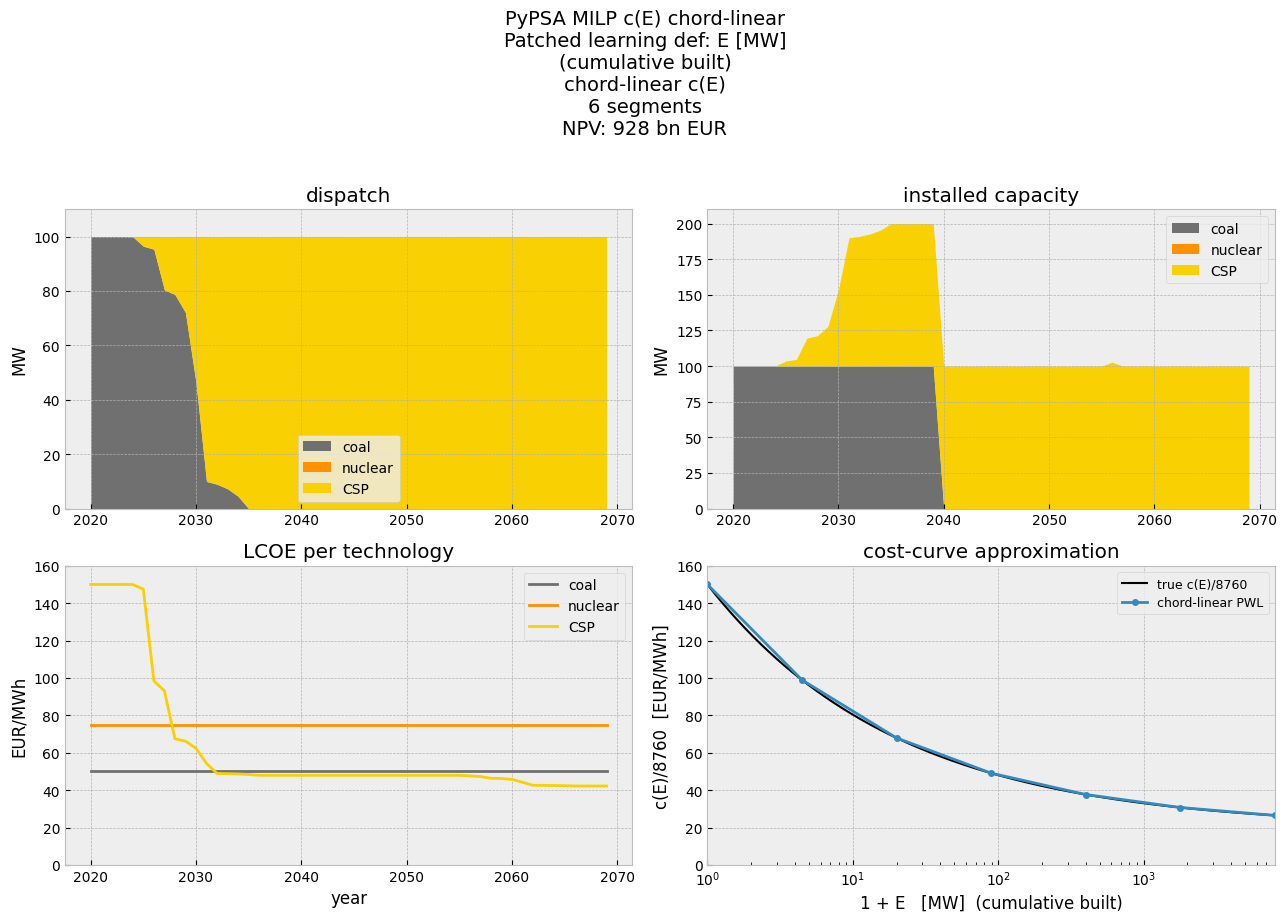

In [8]:
dispatch, capacity, _ = extract_pypsa(n)
E_opt = n.model["csp_E"].solution.to_pandas()
lcoe = milp_lcoe(E_opt)
save_results("milp_notebook_chord", dispatch, capacity, lcoe, obj)

dashboard(
    make_title(
        "PyPSA MILP c(E) chord-linear",
        "Patched learning def: E [MW]\n(cumulative built)",
        "chord-linear c(E)",
        N_SEG_CHORD,
        obj,
    ),
    dispatch,
    capacity,
    lcoe,
    lambda ax: plot_approx_c(ax, E_BREAK_CHORD, "chord"),
)


## Model 4 — MILP chord-linear $TC(E)$

> **Stack:** `pypsa` + `linopy` + `gurobi`

Models 2 and 3 linearised the *marginal* cost $c(E)$ and paid for a build at its
own segment's price. This model prices builds by the **integral** $TC(E)$ —
the true cost of expanding from $E_{a-1}$ to $E_a$ is the **area under** the
learning curve:

$$
\text{cost}(E_{a-1} \to E_a) = \int_{E_{a-1}}^{E_a} c(x)\,dx
  = TC(E_a) - TC(E_{a-1}),
$$

where $TC(E) = \int_0^E c(x)\,dx$ is the **cumulative cost** (antiderivative of
the learning curve). Since $c(E)$ is decreasing, $TC$ is concave. We can use the Barreto doubling scheme to place the breakpoints.


The cost of a build $Q_a$ is the integral of $c(E')$ over the experience gained:
each infinitesimal MW pays the price prevailing at that point on the curve —
not the discounted post-learning price, but also not a fixed pre-learning price.
In closed form:

$$TC(E) = c_{\text{base}}E + \frac{c_0 - c_{\text{base}}}{1-\gamma}\big[(1+E)^{1-\gamma}-1\big].$$

### 4.1 The chord-linear PWL of $TC(E)$

Pick breakpoints $E_0=0<E_1<\dots<E_N$ and evaluate $TC_j=TC(E_j)$ exactly on
the curve. The chord on each segment is the straight line connecting
$(E_j, TC_j)$ to $(E_{j+1}, TC_{j+1})$. We want the optimiser to read off the
chord value at whatever $E_a$ it chooses.

The natural LP tool is a convex combination: introduce $\lambda_j \ge 0$ with
$\sum_j \lambda_j = 1$, then $E_a = \sum_j \lambda_j E_j$ and
$TC_a = \sum_j \lambda_j TC_j$. This works correctly only if *at most two
consecutive* $\lambda_j$ are nonzero — otherwise the LP can mix, say, the first
and last breakpoints, and because $TC$ is concave the straight line between them
lies *below* all the intermediate chords, giving the solver a cheaper cost than
any single segment provides. Without integer constraints the LP would exploit this.

To enforce that exactly one segment is active, we introduce a binary selector
$y_{a,j}$ and split the weight for each segment into a left and right part:

| Symbol | Type | Unit | Meaning |
|--------|------|------|--------|
| $j = 0,\dots,N-1$ | index | — | segment index |
| $y_{a,j} \in \{0,1\}$ | binary | — | 1 if year $a$ falls in segment $j$ |
| $\lambda^L_{a,j} \ge 0$ | continuous | — | weight on left endpoint $E_j$ |
| $\lambda^R_{a,j} \ge 0$ | continuous | — | weight on right endpoint $E_{j+1}$ |
| $E_a \ge 0$ | continuous | MW | cumulative experience in year $a$ |
| $TC_a \ge 0$ | continuous | M€ | cumulative cost in year $a$ |

and the following constraints:

| Constraint | Expression | Purpose |
|------------|------------|---------|
| one active segment | $\sum_j y_{a,j} = 1$ | exactly one segment is selected |
| weights tied to binary | $\lambda^L_{a,j} + \lambda^R_{a,j} = y_{a,j}$ | weights are zero unless segment $j$ is active |
| experience on chord | $E_a = \sum_j\!\big(\lambda^L_{a,j}E_j + \lambda^R_{a,j}E_{j+1}\big)$ | $E_a$ is a convex combination within the active segment |
| cost on chord | $TC_a = \sum_j\!\big(\lambda^L_{a,j}TC_j + \lambda^R_{a,j}TC_{j+1}\big)$ | $TC_a$ reads the chord value at $E_a$ |


### 4.2 Creating the breakpoints

$TC(E)$ is steep at small $E$ and nearly flat at large $E$. Barreto's rule places breakpoints so each segment carries **double** the $TC$ increment of the previous one, concentrating resolution where the curve bends most.

With $N$ segments, the per-segment cost shares are $2^j$ for $j = 0,\dots,N-1$, normalised to sum to $TC_{\text{total}}$:

$$\Delta TC_j = TC_{\text{total}} \cdot \frac{2^j}{2^N - 1}.$$

Cost breakpoints follow by cumulation, and capacity breakpoints by inverting $TC$ numerically. For $N=5$, the first breakpoint lands near $E_1 \approx 7\,\text{MW}$ while the last segment spans ${\approx}205 \to 500\,\text{MW}$.


### 4.3 The experience axis and the objective patch

$$E_a = E_{a-1} + Q_{\text{CSP},a},\qquad E_{Y_0}=Q_{\text{CSP},Y_0},$$

where $Q_{\text{CSP},a}$ is the **new build** in year $a$. $E$ never decreases and
never forgets — once built, a MW contributes to experience forever, even after it
retires. One MW built buys exactly one unit of experience.

The **objective patch**: CSP `capital_cost` is set to 0 to avoid double-counting,
and the learning capex is added explicitly,

$$\text{extra}=\sum_a \underbrace{(TC_a-TC_{a-1})}_{\text{inv}_a}\,
\underbrace{\mathrm{adf}(a,L_{\text{CSP}})}_{\sum_{b=a}^{a+L-1}(1+r)^{-(b-Y_0)}},$$

the same lifetime-summed discounting PyPSA applies to coal and nuclear
`capital_cost`.


### Code

In [9]:
from scipy.optimize import brentq

# ---- Barreto-doubling breakpoints of TC(E) ----------------------------------
N_SEG = 5
E_MAX = 500.0
_TC_TOTAL = tc_csp(E_MAX)  # total cost budget to subdivide
_DTC = [
    _TC_TOTAL * (2**j) / (2**N_SEG - 1) for j in range(N_SEG)
]  # doubling shares: weights 1,2,4,8,16 normalised to sum = _TC_TOTAL
TC_BREAK = np.cumsum(
    [0.0] + _DTC
)  # TC values at breakpoints; TC_BREAK[0]=0, TC_BREAK[-1]=_TC_TOTAL
E_BREAK = np.array(
    [0.0]
    + [
        brentq(
            lambda E, tc=tc: tc_csp(E) - tc, 0.0, E_MAX + 1e-3
        )  # invert TC analytically: find E s.t. TC(E)=tc
        for tc in TC_BREAK[1:]
    ]
)

Some intuition:

`_TC_TOTAL` — total cumulative cost at the upper bound: $TC(E_{\max})$.

`_DTC` — per-segment cost increments with doubling weights $2^j$, normalised so they sum to `_TC_TOTAL`.

`TC_BREAK` — cumulative sum of `_DTC` prepended with 0; gives the $TC$ value at each breakpoint. `TC_BREAK[0] = 0`, `TC_BREAK[-1] = _TC_TOTAL`.

`E_BREAK` — capacity breakpoints obtained by numerically inverting $TC$: for each `TC_BREAK[k]`, find $E_k$ such that $TC(E_k) = $ `TC_BREAK[k]`.



In [10]:
def add_learning(n):
    m = n.model
    period = pd.Index(YEARS, name="period")
    seg = pd.Index(range(N_SEG), name="seg")

    y = m.add_variables(binary=True, coords=[period, seg], name="csp_y")
    lamL = m.add_variables(lower=0.0, coords=[period, seg], name="csp_lamL")
    lamR = m.add_variables(lower=0.0, coords=[period, seg], name="csp_lamR")
    E = m.add_variables(lower=0.0, coords=[period], name="csp_E")
    TC = m.add_variables(lower=0.0, coords=[period], name="csp_TC")

    m.add_constraints(y.sum("seg") == 1, name="csp_y_sum")
    m.add_constraints(lamL + lamR - y == 0, name="csp_lam_eq")
    EL = xr.DataArray(E_BREAK[:-1], coords=[seg], dims=["seg"])
    ER = xr.DataArray(E_BREAK[1:], coords=[seg], dims=["seg"])
    TL = xr.DataArray(TC_BREAK[:-1], coords=[seg], dims=["seg"])
    TR = xr.DataArray(TC_BREAK[1:], coords=[seg], dims=["seg"])
    m.add_constraints((lamL * EL + lamR * ER).sum("seg") - E == 0, name="csp_E_def")
    m.add_constraints((lamL * TL + lamR * TR).sum("seg") - TC == 0, name="csp_TC_def")

    # E[a] = E[a-1] + Q[a]  (cumulative built)
    p_nom = m["Generator-p_nom"]
    for i, a in enumerate(YEARS):
        Q_a = p_nom.at[f"CSP_{a}"]
        if i == 0:
            m.add_constraints(E.at[a] - Q_a == 0, name=f"csp_E_track_{a}")
        else:
            m.add_constraints(
                E.at[a] - E.at[YEARS[i - 1]] - Q_a == 0, name=f"csp_E_track_{a}"
            )

    # inv[a] = TC[a] - TC[a-1], added to objective with lifetime discounting
    inv = m.add_variables(lower=-1e15, coords=[period], name="csp_inv")
    for i, a in enumerate(YEARS):
        if i == 0:
            m.add_constraints(inv.at[a] - TC.at[a] == 0, name=f"csp_inv_def_{a}")
        else:
            m.add_constraints(
                inv.at[a] - TC.at[a] + TC.at[YEARS[i - 1]] == 0, name=f"csp_inv_def_{a}"
            )

    adf_arr = xr.DataArray(
        [adf(a, LIFETIME["CSP"]) for a in YEARS], coords=[period], dims=["period"]
    )
    m.add_objective(m.objective.expression + (inv * adf_arr).sum(), overwrite=True)


n = build_network()
n.optimize.create_model(multi_investment_periods=True)
add_learning(n)
n.optimize.solve_model(solver_name="gurobi", solver_options={"OutputFlag": 0})
obj = float(n.model.objective.value) / 1e6 + coal_constant()
print(f"MILP TC(E): NPV={obj:.1f} bn EUR")


Index(['bus'], dtype='object', name='name')
/tmp/ipykernel_848742/2858001572.py:49: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.



Set parameter TokenServer to value "license.ensys.tu-berlin.de"


INFO:gurobipy:Set parameter TokenServer to value "license.ensys.tu-berlin.de"


Read LP format model from file /tmp/linopy-problem-igycg4q3.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-igycg4q3.lp


Reading time = 0.01 seconds


INFO:gurobipy:Reading time = 0.01 seconds


obj: 7751 rows, 4575 columns, 17768 nonzeros


INFO:gurobipy:obj: 7751 rows, 4575 columns, 17768 nonzeros


MILP TC(E): NPV=983.5 bn EUR


Cumulative CSP built by 2070: E = 200 MW


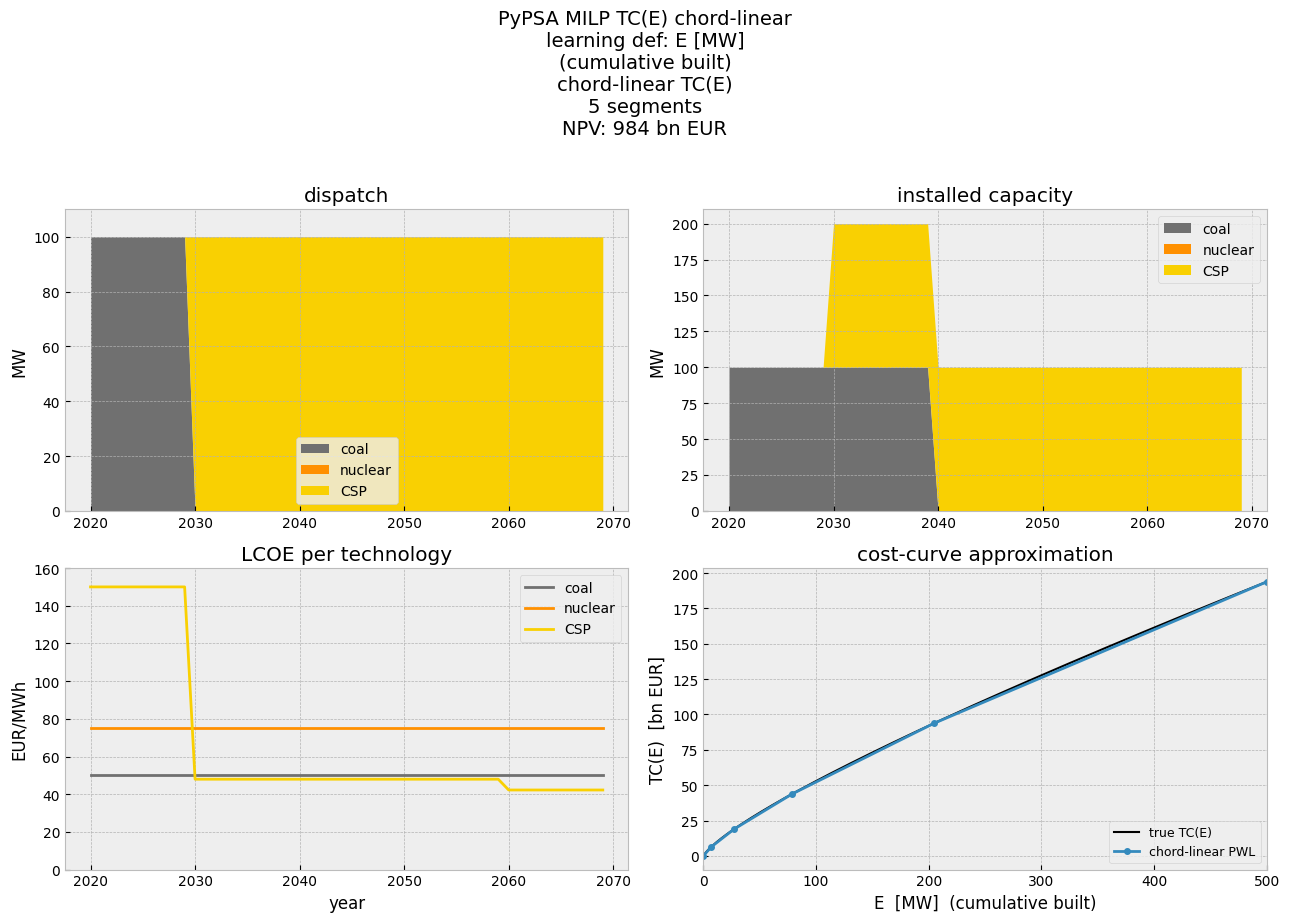

In [11]:
dispatch, capacity, _ = extract_pypsa(n)
E_opt = n.model["csp_E"].solution.to_pandas()
lcoe = milp_lcoe(E_opt)
save_results("milp_tce", dispatch, capacity, lcoe, obj)
print(f"Cumulative CSP built by 2070: E = {E_opt.iloc[-1]:.0f} MW")

dashboard(
    make_title(
        "PyPSA MILP TC(E) chord-linear",
        "learning def: E [MW]\n(cumulative built)",
        "chord-linear TC(E)",
        N_SEG,
        obj,
    ),
    dispatch,
    capacity,
    lcoe,
    lambda ax: plot_approx_TC(ax, E_BREAK),
)


## Model 5 — MILP, TC(E) + learning time delay

Model 4 has one pitfall. The chord $TC_a - TC_{a-1}$ is the *average* cost per unit of capacity built over the range $[E_{a-1},\, E_{a-1}+Q_a]$. Because $TC$ is concave, this average lies *below* the left-endpoint marginal cost $c(E_{a-1})$ — and the gap widens as $Q_a$ grows. The optimiser exploits this by **bunching many periods of investment into a single large build**: one big jump down the learning curve yields a steeper chord discount than spreading the same capacity across many periods.

This problem is addressed in Model 5, which charges period $a$ at the instantaneous cost **at the start of that period**: $c(E_{a-1})$. This is the left-endpoint slope of $TC$, which for a concave curve equals or exceeds the chord slope for any $Q_a > 0$. No matter how much capacity you add in period $a$, the per-unit price is fixed at what the technology costs *before* you build. Bundling no longer saves money. The cost formula changes from Model 4 to Model 5 as:

$$
\underbrace{TC(E_a)-TC(E_{a-1})}_{\text{Model 4: chord integral (area under curve)}}
\quad\longrightarrow\quad
\underbrace{c(E_{a-1})\cdot Q_a}_{\text{Model 5: rectangle at start-of-period cost}}
$$

**To achieve this, we link segments across periods.** The binary $y_{a-1,j}$ (equal to 1 on whichever segment held $E_{a-1}$ at the end of the previous period) "passes forward" the current price. New investment variables $x^{\text{diff}}_{a,j}\ge 0$ distribute $Q_a$ across segments but are restricted to that active segment:

$$
\sum_j x^{\text{diff}}_{a,j}=Q_a,
\qquad
x^{\text{diff}}_{a,j}\le E_{\max}\,y_{a-1,j},
\qquad
\text{inv}_a=\sum_j s_j\,x^{\text{diff}}_{a,j},
$$

where $s_j=(TC_{j+1}-TC_j)/(E_{j+1}-E_j)$ is the slope of segment $j$. Because exactly one $y_{a-1,j}=1$, the effective unit cost is $s_j\approx c(E_{a-1})$. The first period has no predecessor and is priced directly at $c_0$.

| Symbol | Description | Unit |
|:---|:---|:---|
| $s_j = \dfrac{TC_{j+1}-TC_j}{E_{j+1}-E_j}$ | segment slope = average unit cost on segment $j$ | M€/MW |
| $x^{\text{diff}}_{a,j}$ | capacity built in period $a$, billed at segment $j$ | MW |
| $y_{a,j}$ | 1 if segment $j$ was active at end of period $a$ | — (binary) |
| $E_{\max}$ | width of one segment (upper bound per segment) | MW |
| $\text{inv}_a$ | total investment cost in period $a$ | M€ |

### Objective contribution

The learning cost term added to the NPV objective is:

$$
\text{NPV}_{\text{learning}} =
\underbrace{c_0 \cdot \alpha_0 \cdot Q_0}_{\text{first period at } c_0}
+
\underbrace{\sum_{a>0}\sum_j s_j \cdot \alpha_a \cdot x^{\text{diff}}_{a,j}}_{\text{future periods at prev-segment slope}}
$$

where $\alpha_a = \text{adf}(a, L)$ is the annuity-discount factor for period $a$ and lifetime $L$.

- **Period 0** charges the initial cost $c_0$ directly — `extra_first = C0 * adf(YEARS[0], L) * Q_0`.
- **Periods $a > 0$** are charged via `x_diff`: each MW is billed at `SEG_SLOPE[j]`, the slope of whatever segment was active in period $a-1$. The constraint `x_diff[a,j] <= E_max * y[a-1,j]` ensures only segment $j^*$ (the one active last period) can receive any capacity, so the effective price is $s_{j^*} \approx c(E_{a-1})$.
- All other costs (dispatch, coal, etc.) are carried over unchanged from the base model.

In [12]:
# reuse the Barreto breakpoints; add the per-segment slopes
N_SEG_DELAY = N_SEG
E_BREAK_DELAY = E_BREAK
TC_BREAK_DELAY = TC_BREAK
E_MAX_DELAY = E_MAX
SEG_SLOPE = (TC_BREAK_DELAY[1:] - TC_BREAK_DELAY[:-1]) / (
    E_BREAK_DELAY[1:] - E_BREAK_DELAY[:-1]
)


def add_learning_delay(n):
    m = n.model
    p_nom = m["Generator-p_nom"]
    period = pd.Index(YEARS, name="period")
    seg = pd.Index(range(N_SEG_DELAY), name="seg")

    # locate E[a] on the curve (binaries y carry the active segment per period)
    y = m.add_variables(binary=True, coords=[period, seg], name="csp_y")
    lamL = m.add_variables(lower=0.0, coords=[period, seg], name="csp_lamL")
    lamR = m.add_variables(lower=0.0, coords=[period, seg], name="csp_lamR")
    E = m.add_variables(lower=0.0, coords=[period], name="csp_E")

    m.add_constraints(y.sum("seg") == 1, name="csp_y_sum")
    m.add_constraints(lamL + lamR - y == 0, name="csp_lam_eq")
    EL = xr.DataArray(E_BREAK_DELAY[:-1], coords=[seg], dims=["seg"])
    ER = xr.DataArray(E_BREAK_DELAY[1:], coords=[seg], dims=["seg"])
    m.add_constraints((lamL * EL + lamR * ER).sum("seg") - E == 0, name="csp_E_def")

    for i, a in enumerate(YEARS):
        Q_a = p_nom.at[f"CSP_{a}"]
        if i == 0:
            m.add_constraints(E.at[a] - Q_a == 0, name=f"csp_E_track_{a}")
        else:
            m.add_constraints(
                E.at[a] - E.at[YEARS[i - 1]] - Q_a == 0, name=f"csp_E_track_{a}"
            )

    # time-delay pricing: build in a is charged at the segment active in a-1
    future = pd.Index(YEARS[1:], name="period")
    x_diff = m.add_variables(lower=0.0, coords=[future, seg], name="csp_x_diff")
    for i, a in enumerate(YEARS[1:], start=1):
        prev = YEARS[i - 1]
        Q_a = p_nom.sel(name=f"CSP_{a}")
        m.add_constraints(
            x_diff.sel(period=a).sum("seg") + (-1) * Q_a == 0, name=f"csp_xdiff_sum_{a}"
        )
        m.add_constraints(
            x_diff.sel(period=a) - E_MAX_DELAY * y.sel(period=prev) <= 0,
            name=f"csp_xdiff_ub_{a}",
        )

    # objective: first period at c0, later periods at previous segment's slope
    L = LIFETIME["CSP"]
    extra_first = C0 * adf(YEARS[0], L) * p_nom.sel(name=f"CSP_{YEARS[0]}")
    slope_adf = xr.DataArray(
        [[SEG_SLOPE[j] * adf(a, L) for j in range(N_SEG_DELAY)] for a in YEARS[1:]],
        coords=[future, seg],
        dims=["period", "seg"],
    )
    extra_future = (x_diff * slope_adf).sum()
    m.add_objective(m.objective.expression + extra_future + extra_first, overwrite=True)


n = build_network()
n.optimize.create_model(multi_investment_periods=True)
add_learning_delay(n)
n.optimize.solve_model(solver_name="gurobi", solver_options={"OutputFlag": 0})
obj = float(n.model.objective.value) / 1e6 + coal_constant()
print(f"MILP time-delay: NPV={obj:.1f} bn EUR")


Index(['bus'], dtype='object', name='name')
/tmp/ipykernel_848742/2331005056.py:65: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.



Set parameter TokenServer to value "license.ensys.tu-berlin.de"


INFO:gurobipy:Set parameter TokenServer to value "license.ensys.tu-berlin.de"


Read LP format model from file /tmp/linopy-problem-114ayxxp.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-114ayxxp.lp


Reading time = 0.02 seconds


INFO:gurobipy:Reading time = 0.02 seconds


obj: 7945 rows, 4720 columns, 17903 nonzeros


INFO:gurobipy:obj: 7945 rows, 4720 columns, 17903 nonzeros


MILP time-delay: NPV=989.5 bn EUR


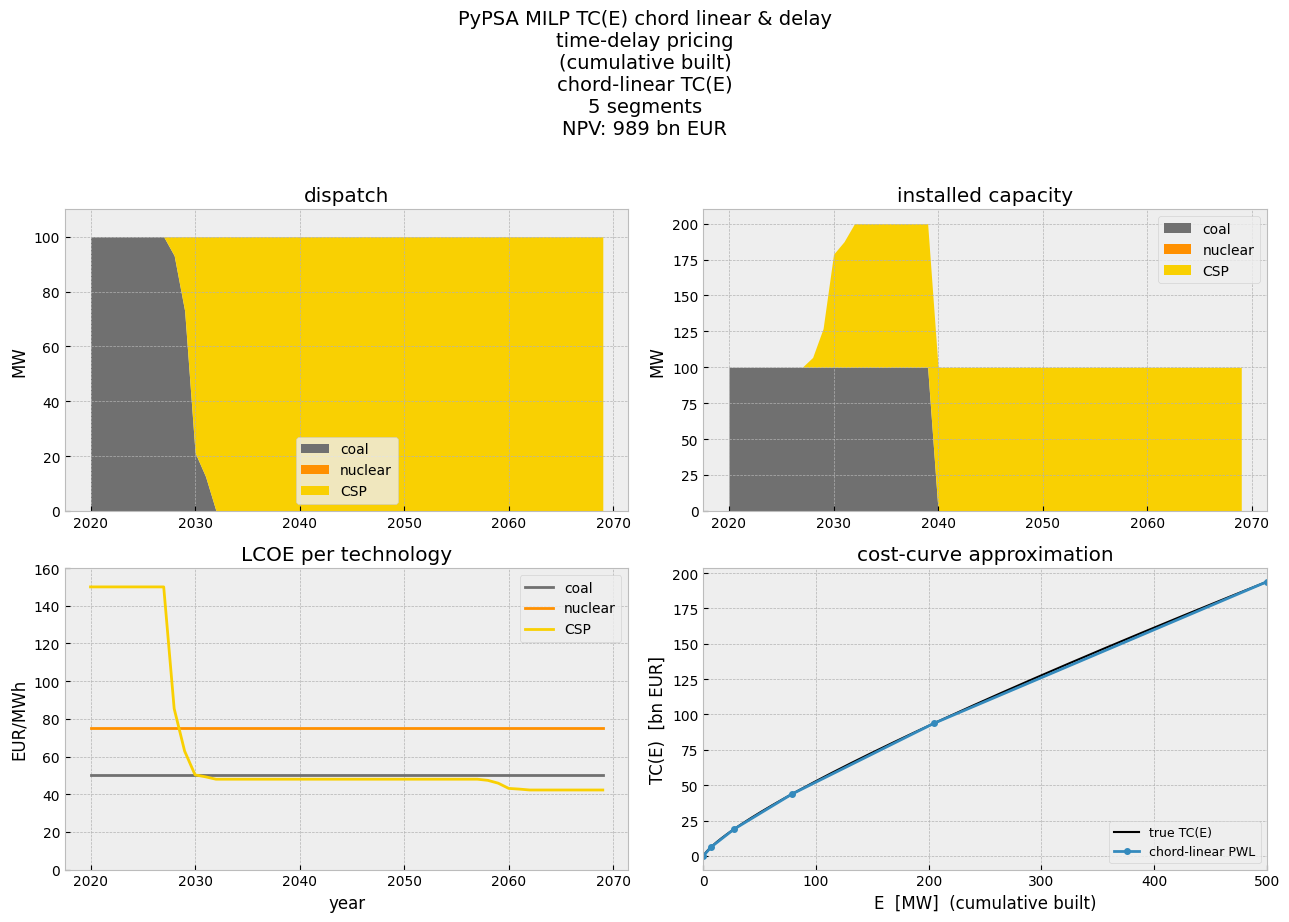

In [13]:
dispatch, capacity, _ = extract_pypsa(n)
E_opt = n.model["csp_E"].solution.to_pandas()
lcoe = milp_lcoe(E_opt)
save_results("milp_tce_delay", dispatch, capacity, lcoe, obj)

dashboard(
    make_title(
        "PyPSA MILP TC(E) chord linear & delay",
        "time-delay pricing\n(cumulative built)",
        "chord-linear TC(E)",
        N_SEG_DELAY,
        obj,
    ),
    dispatch,
    capacity,
    lcoe,
    lambda ax: plot_approx_TC(ax, E_BREAK_DELAY),
)


## Putting it all together — the five-model comparison

The grid below reads the five CSVs we just wrote and lays the models side by side.

Reading across the row of LCOE panels is the punchline: every model rides the
**same cumulative-built experience axis** and bottoms out at the same ~42 €/MWh
CSP floor. What changes column to column is *how the cost is approximated and
priced* — true $c(E)$, stepped/chord $c(E)$, integral $TC(E)$, or time-delayed
$TC(E)$.


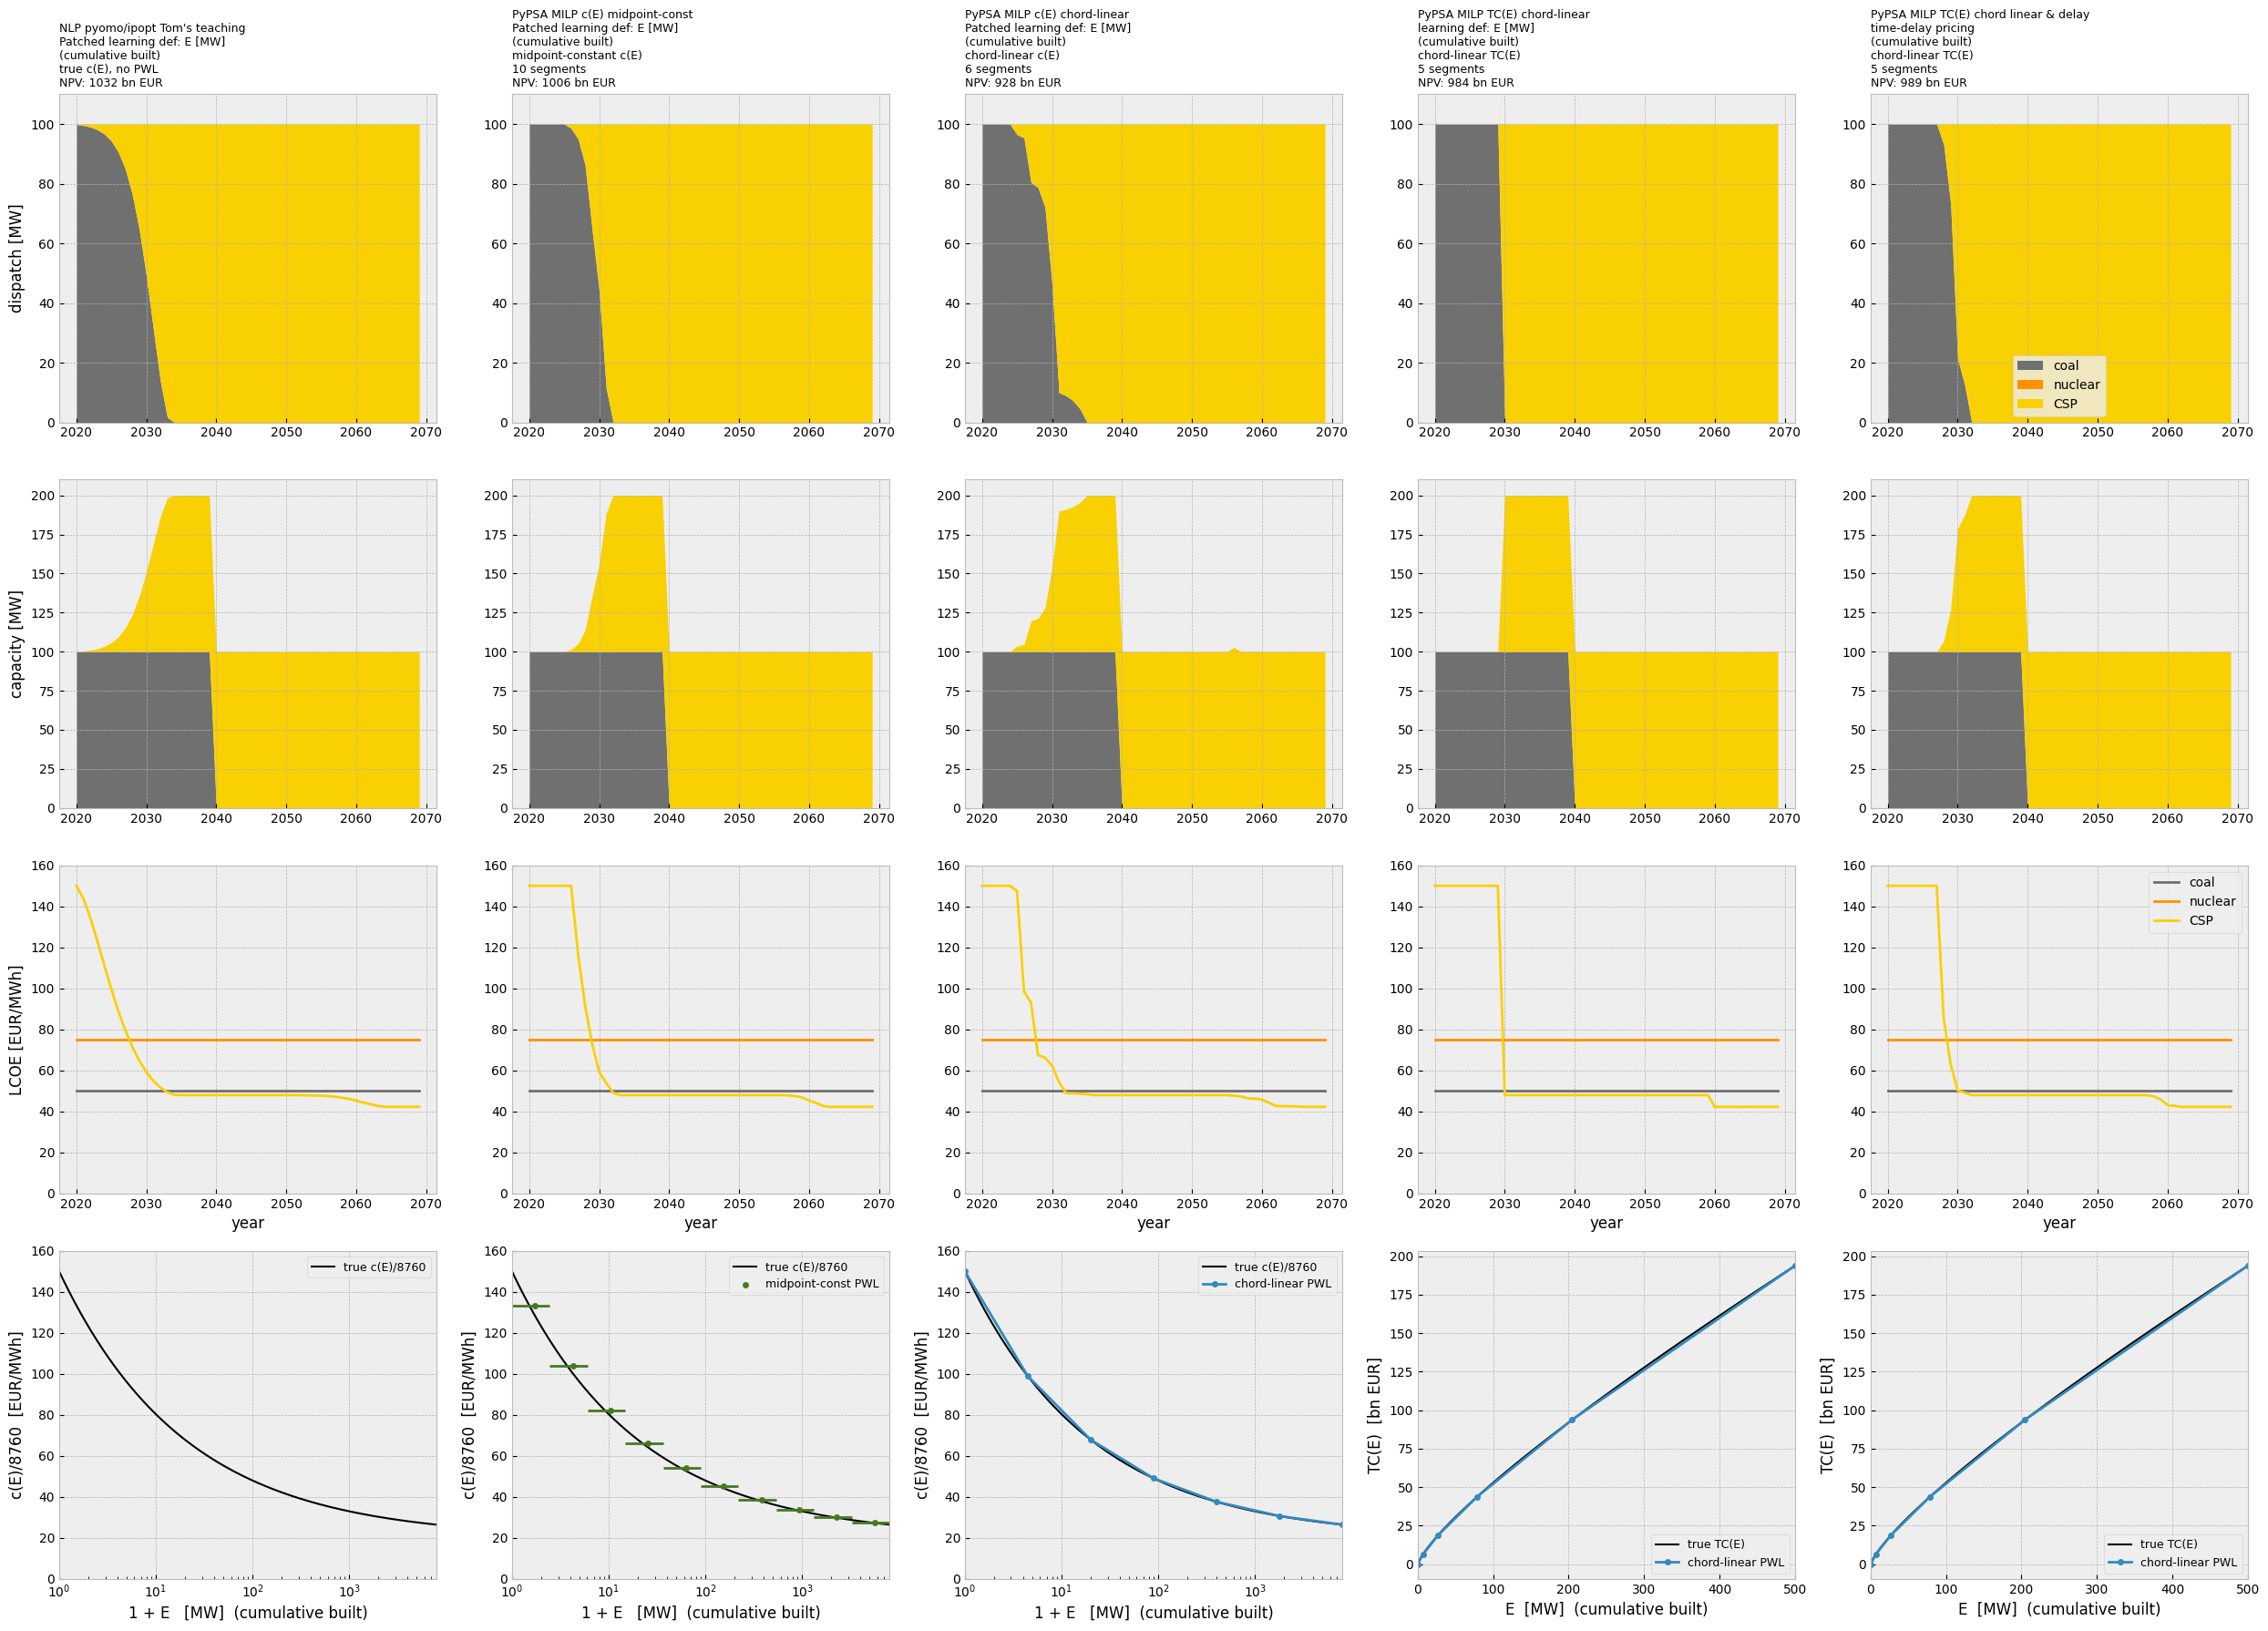

In [14]:
def _load_csv(prefix):
    df = pd.read_csv(f"{prefix}.csv", index_col=[0, 1])
    out = {}
    for key in ["dispatch", "capacity", "lcoe"]:
        sub = df.loc[key][TECHS].astype(float)
        sub.index = sub.index.astype(int)
        out[key] = sub.clip(lower=0) if key != "lcoe" else sub
    meta = df.loc["meta"]["value"]
    out["obj"] = float(meta["objective"])
    return out


runs = [
    dict(
        prefix="ipopt",
        title=make_title(
            "NLP pyomo/ipopt Tom's teaching",
            "Patched learning def: E [MW]\n(cumulative built)",
            "true c(E), no PWL",
            None,
            None,
        ),
        approx=lambda ax: plot_approx_c(ax, E_BREAK_MID, "true"),
    ),
    dict(
        prefix="milp_notebook",
        title=make_title(
            "PyPSA MILP c(E) midpoint-const",
            "Patched learning def: E [MW]\n(cumulative built)",
            "midpoint-constant c(E)",
            N_SEG_MID,
            None,
        ),
        approx=lambda ax: plot_approx_c(ax, E_BREAK_MID, "midpoint"),
    ),
    dict(
        prefix="milp_notebook_chord",
        title=make_title(
            "PyPSA MILP c(E) chord-linear",
            "Patched learning def: E [MW]\n(cumulative built)",
            "chord-linear c(E)",
            N_SEG_CHORD,
            None,
        ),
        approx=lambda ax: plot_approx_c(ax, E_BREAK_CHORD, "chord"),
    ),
    dict(
        prefix="milp_tce",
        title=make_title(
            "PyPSA MILP TC(E) chord-linear",
            "learning def: E [MW]\n(cumulative built)",
            "chord-linear TC(E)",
            N_SEG,
            None,
        ),
        approx=lambda ax: plot_approx_TC(ax, E_BREAK),
    ),
    dict(
        prefix="milp_tce_delay",
        title=make_title(
            "PyPSA MILP TC(E) chord linear & delay",
            "time-delay pricing\n(cumulative built)",
            "chord-linear TC(E)",
            N_SEG_DELAY,
            None,
        ),
        approx=lambda ax: plot_approx_TC(ax, E_BREAK_DELAY),
    ),
]

n_cols = len(runs)
fig, axes = plt.subplots(4, n_cols, figsize=(5 * n_cols, 18))

for col, run in enumerate(runs):
    r = _load_csv(run["prefix"])
    last = col == n_cols - 1

    ax = axes[0, col]
    r["dispatch"].plot(
        kind="area", stacked=True, color=COLORS, ax=ax, linewidth=0, legend=last
    )
    ax.set_title(f"{run['title']}\nNPV: {r['obj']:.0f} bn EUR", fontsize=9, loc="left")
    ax.set_ylabel("dispatch [MW]" if col == 0 else "")
    ax.set_ylim(0, 110)
    ax.set_xlabel("")

    ax = axes[1, col]
    r["capacity"].plot(
        kind="area", stacked=True, color=COLORS, ax=ax, linewidth=0, legend=False
    )
    ax.set_ylabel("capacity [MW]" if col == 0 else "")
    ax.set_ylim(0, 210)
    ax.set_xlabel("")

    ax = axes[2, col]
    r["lcoe"].plot(color=COLORS, ax=ax, linewidth=2, legend=last)
    ax.set_ylabel("LCOE [EUR/MWh]" if col == 0 else "")
    ax.set_ylim(0, 160)
    ax.set_xlabel("year")

    run["approx"](axes[3, col])

fig.tight_layout()
fig.savefig("comparison_notebook.png", dpi=110, bbox_inches="tight")
plt.show()


## Bonus model — PyPSA native API (`n.optimize(learning=True)`)

> **Stack:** learning via PyPSA API (`n.optimize(learning=True)`)

> ** Requires the `learning` branch** as this feature is not yet in a released version.
> Install directly from the branch:
> ```
> uv add git+https://github.com/PyPSA/PyPSA.git@learning
> ```

The cost curve is the standard one-factor form **without a cost floor**
(`c(E) = c₀ · (E/E₀)^{-α}`), so the resulting LCOE of CSP, as well as the NPV is lower than in Models 1–5 which use a floored curve. Floor will be added in a future update, together with some other features!


In [15]:
from pypsa.optimization.learning import _learning_breakpoints, _cumulative_cost, _alpha

n = build_network()

# New carrier attributes
n.carriers.loc["CSP", "learning_rate"] = 0.2
n.carriers.loc["CSP", "initial_cost"] = C0
n.carriers.loc["CSP", "global_capacity"] = 1.0
n.carriers.loc["CSP", "max_capacity"] = 500.0

n.optimize(
    multi_investment_periods=True,
    learning=True,
    time_delay=True,
    learning_segments=5,
    solver_name="gurobi",
    solver_options={"OutputFlag": 0},
)
obj = float(n.objective + n.objective_constant) / 1e6
print(f"PyPSA API: NPV={obj:.1f} bn EUR")


/tmp/ipykernel_848742/130809523.py:11: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['bus'], dtype='object', name='name')


Set parameter TokenServer to value "license.ensys.tu-berlin.de"


INFO:gurobipy:Set parameter TokenServer to value "license.ensys.tu-berlin.de"


Read LP format model from file /tmp/linopy-problem-yd0w8sf5.lp


INFO:gurobipy:Read LP format model from file /tmp/linopy-problem-yd0w8sf5.lp


Reading time = 0.01 seconds


INFO:gurobipy:Reading time = 0.01 seconds


obj: 7945 rows, 4720 columns, 17953 nonzeros


INFO:gurobipy:obj: 7945 rows, 4720 columns, 17953 nonzeros


PyPSA API: NPV=695.5 bn EUR


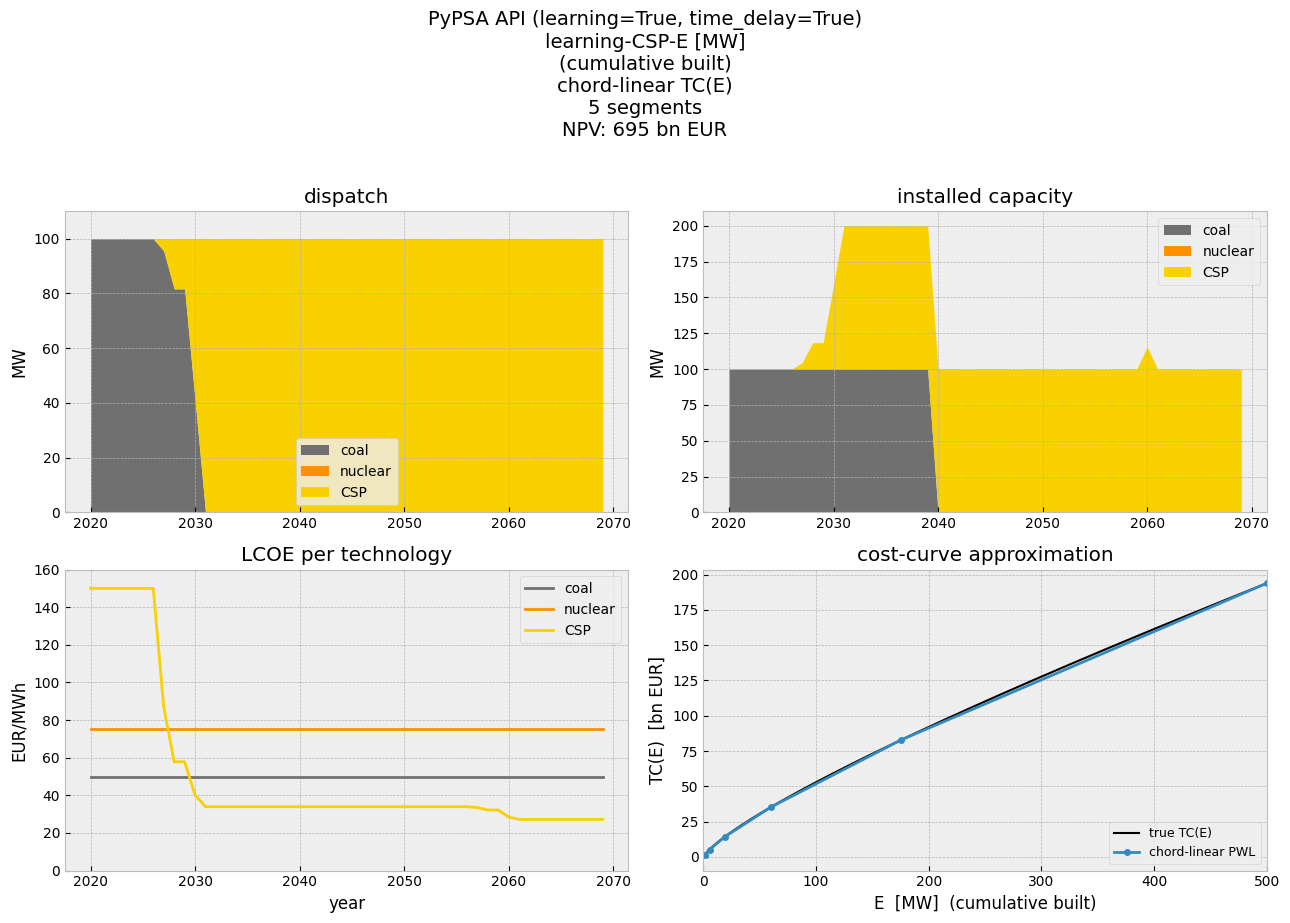

In [16]:
dispatch, capacity, _ = extract_pypsa(n)
E_opt = n.model["learning-CSP-E"].solution.to_pandas()

_a_csp = _alpha(0.2)
E_BREAK_API, _, _ = _learning_breakpoints(0.2, C0, 1.0, 500.0, 5)

# We can't reuse milp_lcoe, as it calls c_csp() which is the floored curve.
lcoe = pd.DataFrame(index=YEARS, columns=TECHS, dtype=float)
for t in ["coal", "nuclear"]:
    lcoe[t] = ANNUITY[t] / 8760.0 + MARGINAL[t]
lcoe["CSP"] = pd.Series(
    {a: C0 * max(E_opt[a], 1.0) ** (-_a_csp) / 8760.0 for a in YEARS}
)

save_results("milp_userapi", dispatch, capacity, lcoe, obj)

dashboard(
    make_title(
        "PyPSA API (learning=True, time_delay=True)",
        "learning-CSP-E [MW]\n(cumulative built)",
        "chord-linear TC(E)",
        5,
        obj,
    ),
    dispatch,
    capacity,
    lcoe,
    lambda ax: plot_approx_TC(ax, E_BREAK_API),
)
